In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler

import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
fmax=16
sfreq=32
paradigm = P300(resample=sfreq, tmin=0, tmax=0.8, fmin=0.5, fmax=fmax)
#dataset = EPFLP300()
#subject, session, run = 1, "session_1", "run_1"
dataset = BNCI2014008()
subject, session, run = 1, "session_0", "run_0"


In [3]:
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Not setting metadata
4200 matching events found
No baseline correction applied


Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,0.000 – 0.781 sec
Baseline,off


No projector specified for this dataset. Please consider the method self.add_proj.


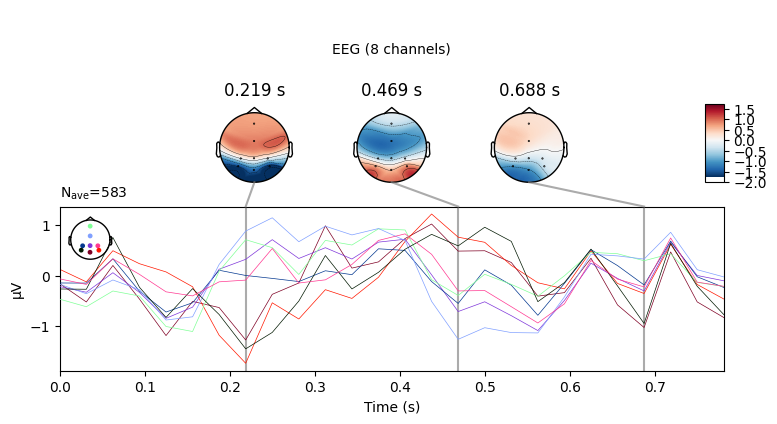

In [4]:
from mne import combine_evoked
target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
contrast = combine_evoked([target, non_target], weights=[1,-1])
_= contrast.plot_joint()

In [5]:
contrast = combine_evoked([epochs['Target'].average(), epochs['NonTarget'].average()], weights=[1,-1])

In [6]:
tmin = epochs.tmin
sfreq = epochs.info['sfreq']

def hankel_tensor(X, y=None):    
    window = .4
    max_lag = .4
    
    n_epochs, n_channels, _ = X.shape
    roi0 = int((0 - tmin)*sfreq)
    roi1 = int((window - tmin)*sfreq)
    n_times = roi1-roi0
    n_lags= int(max_lag*sfreq)
    Xt = np.zeros((n_epochs, n_channels, n_times, n_lags))
    for l in range(n_lags):
        Xt[:,:,:,l] = X[:,:,roi0+l:roi1+l]
    return Xt

In [7]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
from mne.decoding import Scaler

tl.set_backend('cupy')


X = epochs.get_data(picks='eeg')
split = len(epochs)//2
X_train = X[:split]
X_test = X[split:]
y_train = labels[:split]
y_test = labels[split:]




scaler = Scaler(scalings='mean', with_mean=False)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train = tl.tensor(hankel_tensor(X_train))
X_test = tl.tensor(hankel_tensor(X_test))

In [37]:
from hoda.hoda import BTTDA, shrink, oas, HODA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

hoda_lda = Pipeline([
        ('hoda', HODA(
            rank=None,
            max_iter=128,
            tol=1e-6,
            init ='mlsvd',
            verbose=True,
            shrinkage=('oas','oas','oas'),
            toeplitz=(1,),
            solver='od',
            keep_train_info=True,
        )),
        ('lda', LinearDiscriminantAnalysis()),
])

hoda_lda.fit(X_train,y_train)

/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/tensorly/backend/core.py:1106: UserWarning: In partial_svd: converting to NumPy. Check SVD_FUNS for available alternatives if you want to avoid this.
  warnings.warn('In partial_svd: converting to NumPy.'


  0%|          | 0/128 [00:00<?, ?it/s]

[4, 6, 6]
[2, 4, 4]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
[1, 2, 2]
Fit tucker model of rank [1, 2, 2]


Pipeline(steps=[('hoda',
                 HODA(keep_train_info=True, max_iter=128,
                      shrinkage=('oas', 'oas', 'oas'), solver='od',
                      toeplitz=(1,), tol=1e-06, verbose=True)),
                ('lda', LinearDiscriminantAnalysis())])

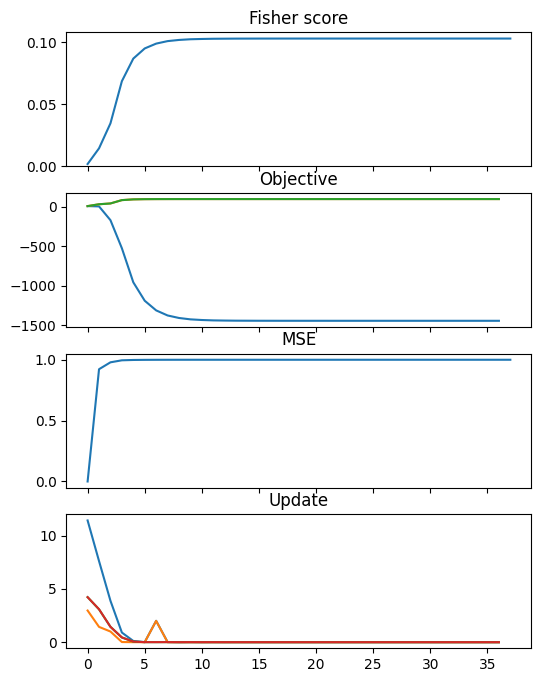

In [38]:
import cupy

fig, axs = plt.subplots(4,1, sharex=True, figsize=(6,8))

axs[0].set_title('Fisher score')
axs[0].plot(hoda_lda['hoda'].train_info_["f_score"])
axs[0].plot(np.asarray(hoda_lda['hoda'].train_info_["mode_f_score"]).T)
axs[0].set_ylim([0,None])

axs[1].set_title('Objective')
axs[1].plot(np.asarray(hoda_lda['hoda'].train_info_["objective"]).T)

axs[2].set_title('MSE')
axs[2].plot(hoda_lda['hoda'].train_info_["mse"])

axs[3].set_title('Update')
axs[3].plot(hoda_lda['hoda'].train_info_["update"])
axs[3].plot(np.asarray(hoda_lda['hoda'].train_info_["mode_update"]).T)


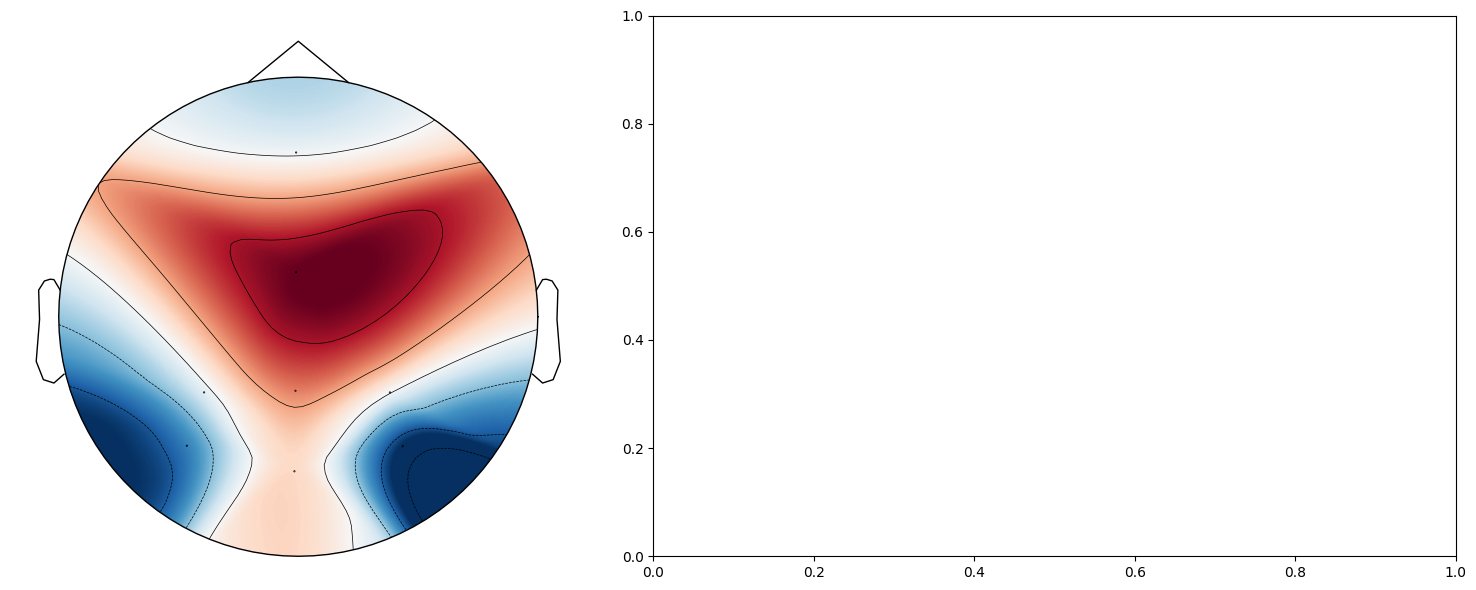

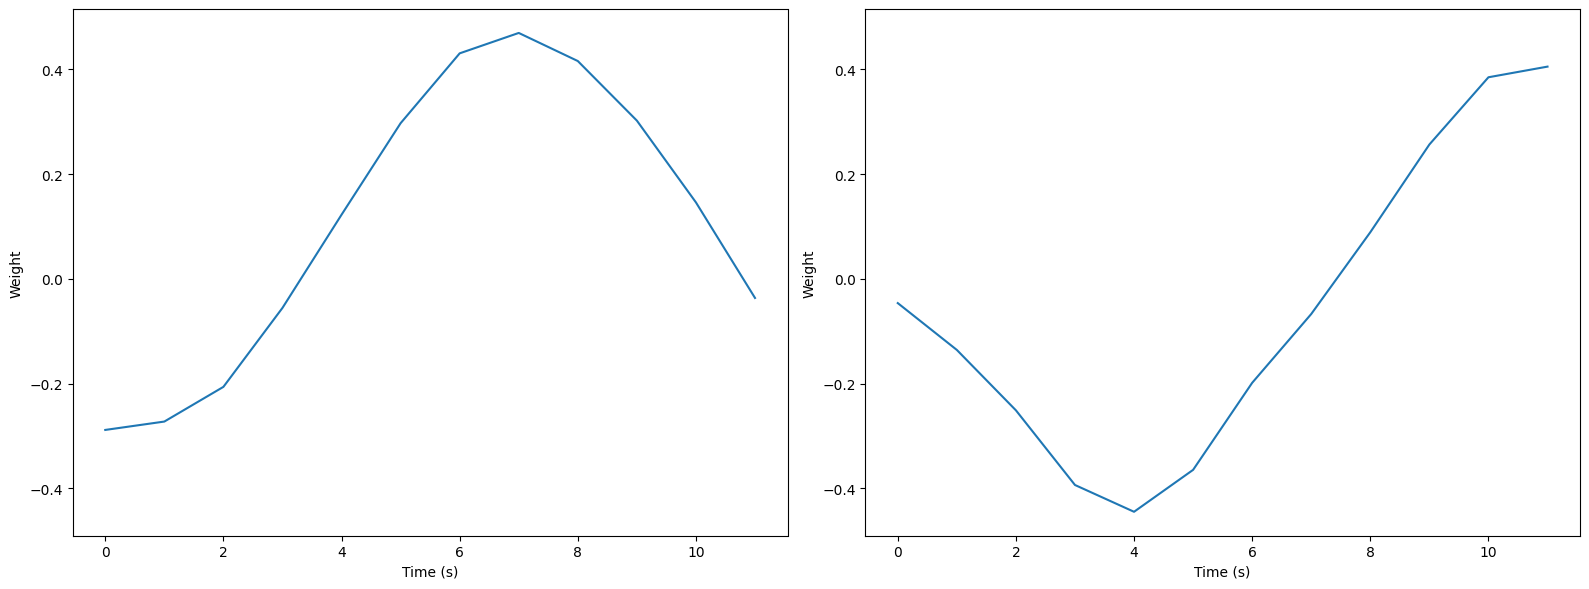

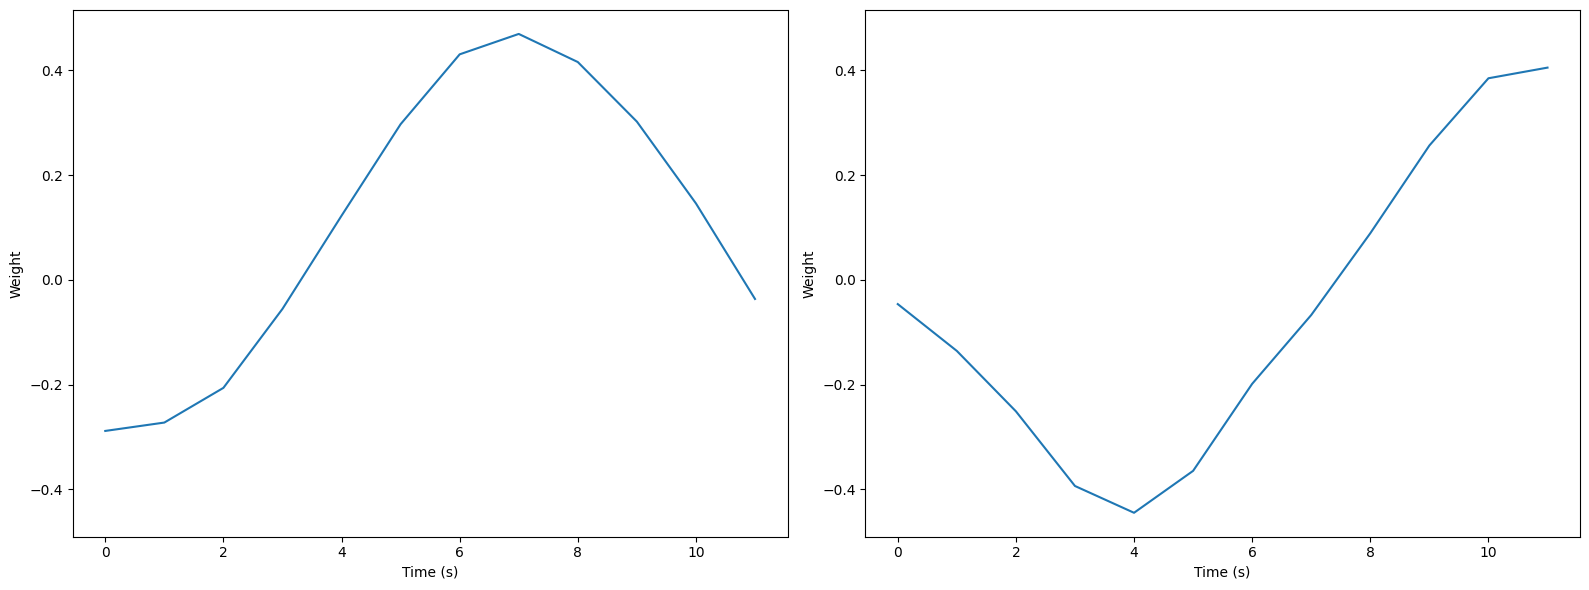

In [30]:
fig, axs = plt.subplots(1,max(hoda_lda['hoda'].rank_[0],2), figsize=(16,6), layout='tight')
for i in range(hoda_lda['hoda'].rank_[0]):
    w = cupy.asnumpy(hoda_lda['hoda'].scalings_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs[i], show=False)

fig, axs = plt.subplots(1,max(hoda_lda['hoda'].rank_[1],2), figsize=(16,6), layout='tight')
for i in range(hoda_lda['hoda'].rank_[1]):
    w = cupy.asnumpy(hoda_lda['hoda'].scalings_[1][:,i])
    axs[i].plot(w)
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel('Weight')
    axs[i].sharey(axs[0])
    
fig, axs = plt.subplots(1,max(hoda_lda['hoda'].rank_[2],2), figsize=(16,6), layout='tight')
for i in range(hoda_lda['hoda'].rank_[2]):
    w = cupy.asnumpy(hoda_lda['hoda'].scalings_[2][:,i])
    axs[i].plot(w)
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel('Weight')
    axs[i].sharey(axs[0])


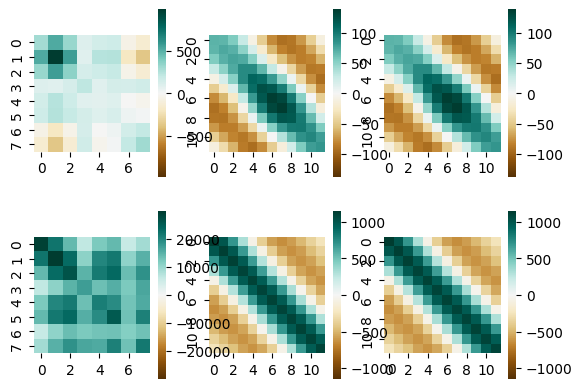

In [31]:
_, axs = plt.subplots(2,3)
for k in range(3):
    scatter_b = cupy.asnumpy(hoda_lda['hoda'].scatter_b_[k])
    vmax = np.max(np.abs(scatter_b))
    axs[0,k].set_aspect('equal')
    sns.heatmap(scatter_b, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[0,k])    
    scatter_w = cupy.asnumpy(hoda_lda['hoda'].scatter_w_[k])
    vmax = np.max(np.abs(scatter_w))
    sns.heatmap(scatter_w, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[1,k])    
    axs[1,k].set_aspect('equal')

<AxesSubplot: xlabel='score', ylabel='Count'>

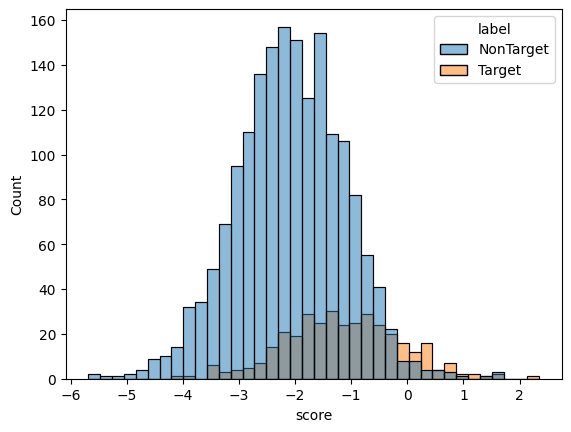

In [32]:
import pandas as pd

train_scores = cupy.asnumpy(hoda_lda.decision_function(X_train))
df = pd.DataFrame(dict(score=cupy.asnumpy(train_scores),label=y_train))
sns.histplot(data=df, x='score', hue='label')

In [33]:
roc_auc_score(y_train,train_scores)

0.7508767346938776

<AxesSubplot: xlabel='score', ylabel='Count'>

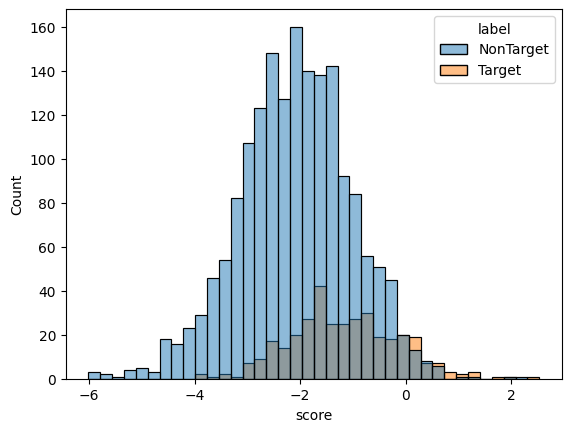

In [34]:
import pandas as pd

test_scores = cupy.asnumpy(hoda_lda.decision_function(X_test))
df = pd.DataFrame(dict(score=cupy.asnumpy(test_scores),label=y_test))
sns.histplot(data=df, x='score', hue='label')

In [35]:
roc_auc_score(y_test,test_scores)

0.7338089795918367